In [1]:
!pip install torc torchvision matplotlib -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 44.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.1/572.1 kB 25.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.1/175.1 MB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.9/79.9 MB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 272.2/272.2 kB 25.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.0/108.0 kB 10.8 MB/s eta 0:00:00


In [13]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

In [12]:
device = "mps" if torch.backends.mps.is_available() else "cpu"
print(f"Using {device} device")

Using mps device


In [15]:
# Load dataset (10 classes)
classes = ('plane','car','bird','cat','deer','dog','frog','horse','ship','truck')

train_data = torchvision.datasets.CIFAR10(root="./data", train=True, download=True, transform=None)
test_data = torchvision.datasets.CIFAR10(root="./data", train=False, download=True, transform=None)

100%|██████████| 170M/170M [46:16<00:00, 61.4kB/s]   
/Users/mehaksingal/Documents/cs_247B_deep_learning/dl_ucla/lib/python3.14/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


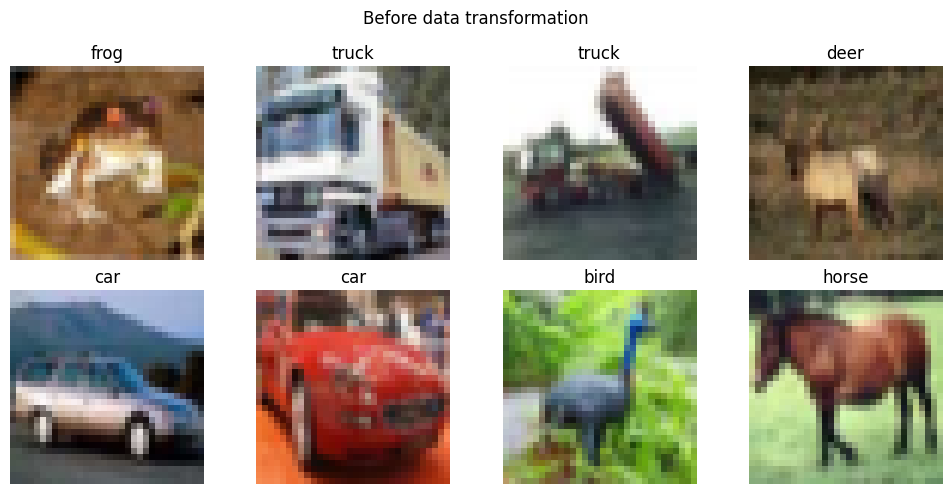

In [16]:
# display images
fig, axes = plt.subplots(2, 4, figsize=(10, 5))
for i, ax in enumerate(axes.flat):
    image, label = train_data[i]  # raw PIL Image, no transform applied yet
    ax.imshow(image)
    ax.set_title(classes[label])
    ax.axis("off")

plt.suptitle("Before data transformation")
plt.tight_layout()
plt.show()

In [17]:
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(), # rearranges dims, changes pixel vals (0 to 1)
    transforms.Normalize((0.4914, 0.4822, 0.4465), # rgb (mean, std)
                         (0.2023, 0.1994, 0.2010))
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), # rgb (mean, std)
                         (0.2023, 0.1994, 0.2010))
])

train_data.transform = transform_train
test_data.transform = transform_test

train_loader = torch.utils.data.DataLoader(train_data, batch_size=128, shuffle=True, num_workers=2)
test_loader = torch.utils.data.DataLoader(test_data, batch_size=100, shuffle=True, num_workers=2)

In [18]:
class BasicBlock(nn.Module):
  def __init__(self, in_channels, out_channels, stride=1):
    super().__init__()
    # if stride = 1 and padding = 1 (out_channels, H, W) else (out_channels, H//2, W//2)
    self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False) # (out_channels, H, W) or (out_channels, H//2, W//2)
    self.bn1 = nn.BatchNorm2d(out_channels) # (out_channels, H, W) or (out_channels, H//2, W//2)
    self.relu = nn.ReLU(inplace=True) # (out_channels, H, W) or (out_channels, H//2, W//2)

    self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False) # (out_channels, H, W) or (out_channels, H//2, W//2)
    self.bn2 = nn.BatchNorm2d(out_channels)
    self.shortcut = nn.Sequential()

    # 1 x 1 conv
    if stride!=1 or in_channels != out_channels:
      self.shortcut = nn.Sequential(
          nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
          nn.BatchNorm2d(out_channels)
      )

  def forward(self, x):
    out = self.conv1(x)
    out = self.bn1(out)
    out = self.relu(out)
    out = self.conv2(out)
    out = self.bn2(out)
    out = out + self.shortcut(x)
    out = self.relu(out)
    return out

In [19]:
class ResNet18(nn.Module):
  def __init__(self, num_classes=10):
    super().__init__()
    self.in_channels = 64

    # first convolution
    self.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False) # (64, H, W)
    self.bn1 = nn.BatchNorm2d(64)
    self.relu = nn.ReLU(inplace=True)

    self.layer1 = self._make_layer(BasicBlock, 64, 2, stride=1) # 64 is output channels, 2 blocks, stride=1 (no downsampling)
    self.layer2 = self._make_layer(BasicBlock, 128, 2, stride=2) # downsampling, inc channels size
    self.layer3 = self._make_layer(BasicBlock, 256, 2, stride=2)
    self.layer4 = self._make_layer(BasicBlock, 512, 2, stride=2)

    self.avgpool = nn.AdaptiveAvgPool2d((1, 1)) # (512,)
    self.fc = nn.Linear(512, num_classes)

  def _make_layer(self, block, out_channels, num_blocks, stride):
    strides = [stride] + [1]*(num_blocks-1) # [stride, 1, 1, ...]
    layers = []
    for stride in strides:
      layers.append(block(self.in_channels, out_channels, stride))
      self.in_channels = out_channels
    return nn.Sequential(*layers)

  def forward(self, x):
    out = self.conv1(x)
    out = self.bn1(out)
    out = self.relu(out)

    out = self.layer1(out)
    out = self.layer2(out)
    out = self.layer3(out)
    out = self.layer4(out)

    out = self.avgpool(out)
    out = out.view(out.size(0), -1)
    out = self.fc(out)
    return out

model = ResNet18().to(device)
print(model)

ResNet18(
  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (shortcut): Sequential()
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=

In [20]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.1, momentum=0.9, weight_decay=5e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=30, gamma=0.1)

In [25]:
num_epochs = 30
train_losses, train_acc_list, test_acc_list = [], [], []

for epoch in range(num_epochs):
  model.train()
  running_loss, correct, total = 0.0, 0, 0
  for images, labels in train_loader:
    images, labels = images.to(device), labels.to(device)

    optimizer.zero_grad()
    outputs = model(images)
    loss = criterion(outputs, labels)
    loss.backward()
    optimizer.step()

    running_loss += loss.item() * images.size(0)
    _, predicted = outputs.max(1)
    total += labels.size(0)
    correct += predicted.eq(labels).sum().item()

  train_loss = running_loss / len(train_loader.dataset)
  train_acc = 100 * (correct / total)
  train_losses.append(train_loss)
  train_acc_list.append(train_acc)

  model.eval()
  correct, total = 0, 0
  with torch.no_grad():
    for inputs, labels in test_loader:
      inputs, labels = inputs.to(device), labels.to(device)
      outputs = model(inputs)
      _, predicted = outputs.max(dim=1) # (values, indices (pred class))
      total += labels.size(0)
      correct += predicted.eq(labels).sum().item()

  test_acc = 100 * (correct / total)
  test_acc_list.append(test_acc)

  scheduler.step()
  print(
      f"Epoch {epoch + 1:02d}/{num_epochs} | "
      f"Train Loss: {train_loss:.4f} | "
      f"Train Accuracy: {train_acc:.2f}% | "
      f"Test Accuracy: {test_acc:.2f}%"
  )

Epoch 01/30 | Train Loss: 0.4484 | Train Accuracy: 84.67% | Test Accuracy: 76.94%
Epoch 02/30 | Train Loss: 0.4429 | Train Accuracy: 84.79% | Test Accuracy: 81.78%
Epoch 03/30 | Train Loss: 0.4330 | Train Accuracy: 85.15% | Test Accuracy: 78.83%
Epoch 04/30 | Train Loss: 0.4208 | Train Accuracy: 85.57% | Test Accuracy: 77.52%
Epoch 05/30 | Train Loss: 0.4207 | Train Accuracy: 85.75% | Test Accuracy: 73.80%
Epoch 06/30 | Train Loss: 0.4157 | Train Accuracy: 85.71% | Test Accuracy: 80.20%
Epoch 07/30 | Train Loss: 0.4052 | Train Accuracy: 86.11% | Test Accuracy: 80.00%
Epoch 08/30 | Train Loss: 0.4090 | Train Accuracy: 86.01% | Test Accuracy: 80.31%
Epoch 09/30 | Train Loss: 0.4009 | Train Accuracy: 86.37% | Test Accuracy: 81.86%
Epoch 10/30 | Train Loss: 0.3983 | Train Accuracy: 86.46% | Test Accuracy: 82.19%
Epoch 11/30 | Train Loss: 0.3850 | Train Accuracy: 86.82% | Test Accuracy: 80.99%
Epoch 12/30 | Train Loss: 0.3851 | Train Accuracy: 86.80% | Test Accuracy: 84.82%
Epoch 13/30 | Tr

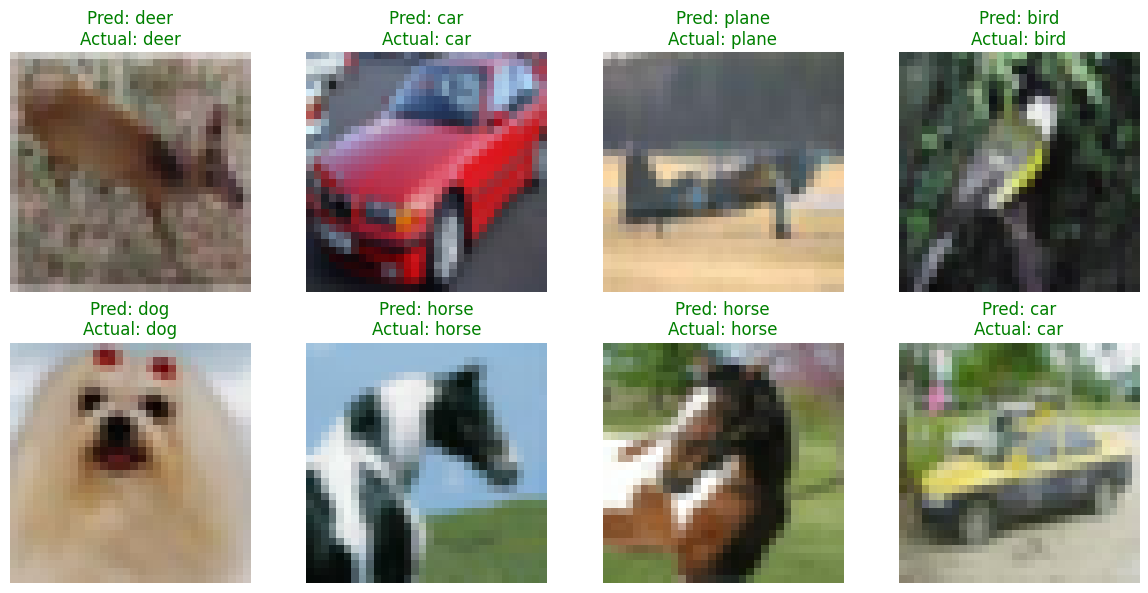

In [26]:
# Test the model on a batch of images and check predicted vs actual labels
model.eval()
images, labels = next(iter(test_loader))
images, labels = images.to(device), labels.to(device)

with torch.no_grad():
    outputs = model(images)
    _, predicted = outputs.max(1)

# Undo normalization for display
mean = torch.tensor([0.4914, 0.4822, 0.4465]).view(3, 1, 1).to(device)
std = torch.tensor([0.2023, 0.1994, 0.2010]).view(3, 1, 1).to(device)
display_images = torch.clamp(images * std + mean, 0, 1).cpu()

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    ax.imshow(display_images[i].permute(1, 2, 0))
    actual = classes[labels[i]]
    pred = classes[predicted[i]]
    color = "green" if pred == actual else "red"
    ax.set_title(f"Pred: {pred}\nActual: {actual}", color=color)
    ax.axis("off")

plt.tight_layout()
plt.show()

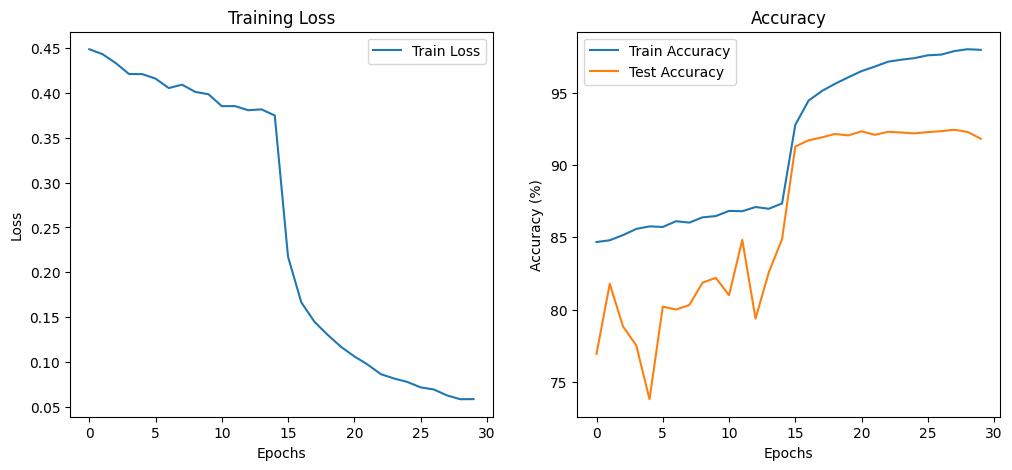

In [27]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(train_losses, label='Train Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.legend()

plt.subplot(1,2,2)
plt.plot(train_acc_list, label='Train Accuracy')
plt.plot(test_acc_list, label='Test Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.title('Accuracy')
plt.legend()

plt.show()